## Max-Cut using divide conquer

### setup

In [1]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import cudaq
from cudaq import spin
import numpy as np

from utils import (
    generate_graph,
    color_graph,
    draw_graph,
    mark_edges,
    brute_force
)

from qaoa import max_cut_hamiltonian, qaoa

In [2]:
n = 7
p = 3/8
seed = 42
shots = 1000

color_dict = {
    "G0": '#8c8c8c',
    "G1": '#fac200',
    "G2": '#0071c5',
    "G3": '#008564',
    "G4": '#cdcdcd',
    "G5": '#76b900',
    "G6": '#ffffff',
}

In [3]:
cudaq.set_target("nvidia", option='mgpu')
cudaq.set_random_seed(seed)

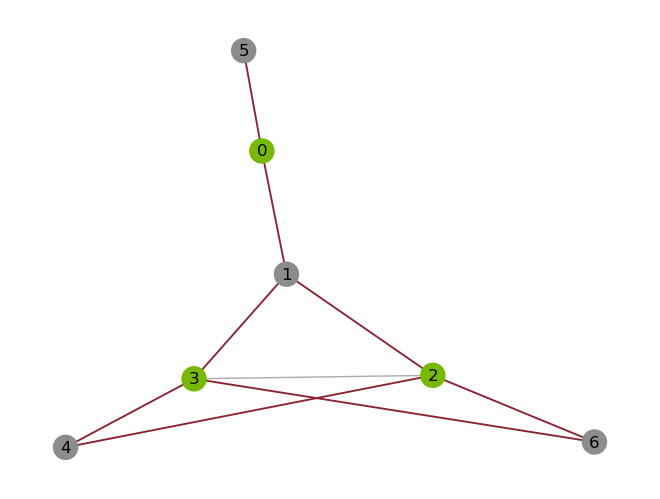

In [4]:
G = generate_graph(n, p)
edge_list = G.edges
max_cut_value, max_cut_edges, max_subset = brute_force(G)
G = color_graph(G, max_subset, 1)
G = mark_edges(G, max_cut_edges)

draw_graph(G)

### standard qaoa

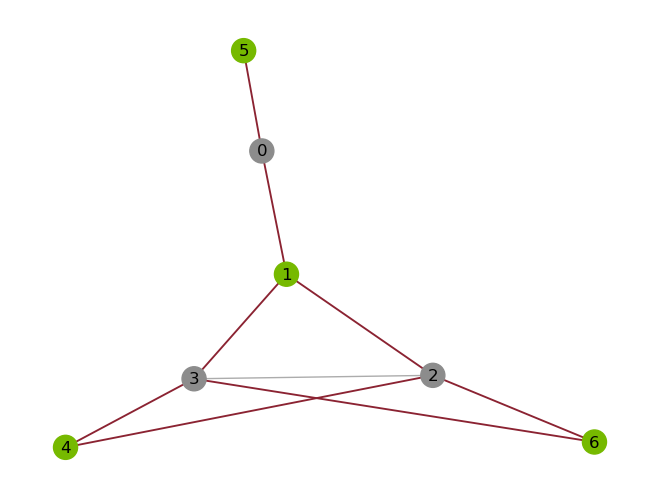

In [5]:
layer_count = 3

def standard_qaoa(G, layer_count, seed=42):
    parameter_count: int = 2 * layer_count

    nodes = list(G.nodes())
    qubit_count = len(nodes)

    qubit_source = list()
    qubit_target = list()
    n_edges = 0
    for u, v in nx.edges(G):
        qubit_source.append(nodes.index(u))
        qubit_target.append(nodes.index(v))
        n_edges += 1

    optimizer = cudaq.optimizers.COBYLA()
    np.random.seed(seed)
    optimizer.initial_parameters = np.random.uniform(
        -np.pi, np.pi,
        parameter_count
    )

    _, optimal_parameters = cudaq.vqe(
        kernel=qaoa,
        spin_operator=max_cut_hamiltonian(qubit_source, qubit_target),
        argument_mapper=lambda parameter_vector: (
            qubit_count,
            layer_count,
            qubit_source,
            qubit_target,
            n_edges,
            parameter_vector
        ),
        optimizer=optimizer,
        parameter_count=parameter_count
    )

    counts = cudaq.sample(
        qaoa,
        qubit_count,
        layer_count,
        qubit_source,
        qubit_target,
        n_edges,
        optimal_parameters,
        shots_count=shots
    )

    return str(counts.most_probable())

result = standard_qaoa(G, layer_count)

G = color_graph(G, [i for i in range(len(result))], 0)
G = color_graph(G, [i for i in range(len(result)) if result[i] == '1'], 1)
G = mark_edges(G, max_cut_edges)

draw_graph(G)

### divide-conquer

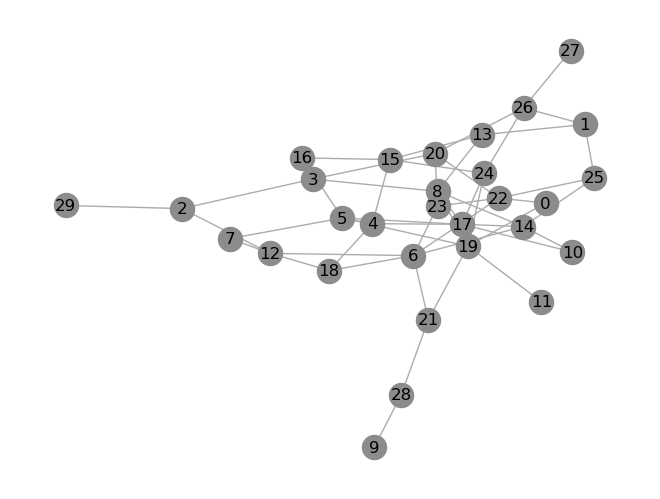

In [6]:
# big graph :O

n = 30
p = 1/10

G = generate_graph(n, p)

edge_list = G.edges
nodes = list(G.nodes())
qubit_count = len(nodes)

qubit_source = list()
qubit_target = list()
n_edges = 0
for u, v in nx.edges(G):
    qubit_source.append(nodes.index(u))
    qubit_target.append(nodes.index(v))
    n_edges += 1

color_map = '#8c8c8c'
edge_color_map = '#acacac'
pos = nx.spring_layout(G, seed=seed)

nx.draw(
    G,
    with_labels=True,
    pos=pos,
    node_color=color_map,
    edge_color=edge_color_map,
)

In [7]:
def devide_graph(G, n):
    greedy_modularity = community.greedy_modularity_communities(
        G, weight=None, resolution=1.1, cutoff=1, best_n=n
    )

    n_subgraphs = len(greedy_modularity)

    graph_dict = dict()
    graph_names = list()
    for i in range(n_subgraphs):
        name='G' + str(i)
        graph_names.append(name)

    for i in range(n_subgraphs):
        nodelist = sorted(list(greedy_modularity[i]))
        graph_dict[graph_names[i]] = nx.subgraph(G, nodelist)

    return graph_dict

In [8]:
divided = devide_graph(G, 12)

In [9]:
divided

{'G0': <networkx.classes.graph.Graph at 0x7392dfbffb10>,
 'G1': <networkx.classes.graph.Graph at 0x7392dfbc7f50>,
 'G2': <networkx.classes.graph.Graph at 0x7392dd1d2c90>,
 'G3': <networkx.classes.graph.Graph at 0x7392dd1d1250>,
 'G4': <networkx.classes.graph.Graph at 0x7392dd1d3f10>}

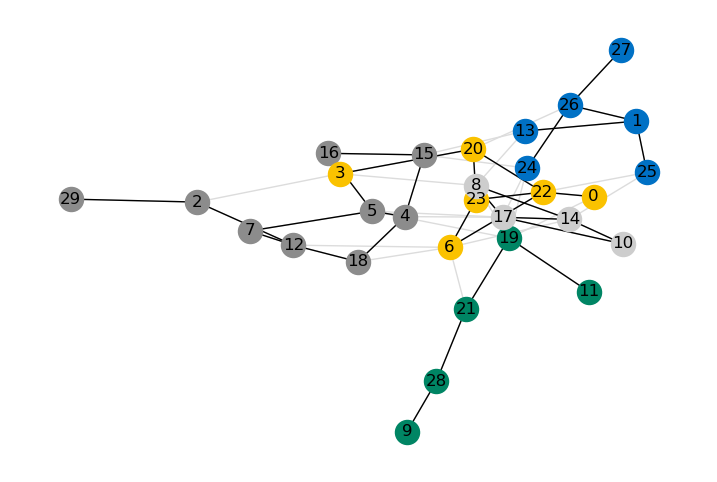

In [10]:
plt.figure(figsize=(9, 6))
nx.draw_networkx_edges(
    G,
    pos=pos,
    edge_color='#dcdcdc',
)

for key in divided:
    nx.draw(divided[key], with_labels=True, pos=pos, node_color=color_dict[key])


In [11]:
layer_count = 1
results = {}
_seed = seed

for key in divided:
    subgraph = divided[key]
    results[key] = standard_qaoa(subgraph, layer_count, seed=_seed)
    _seed += 1
    print(f'{key}: {results[key]}')


G0: 010010101
G1: 110001
G2: 010110
G3: 00101
G4: 1010


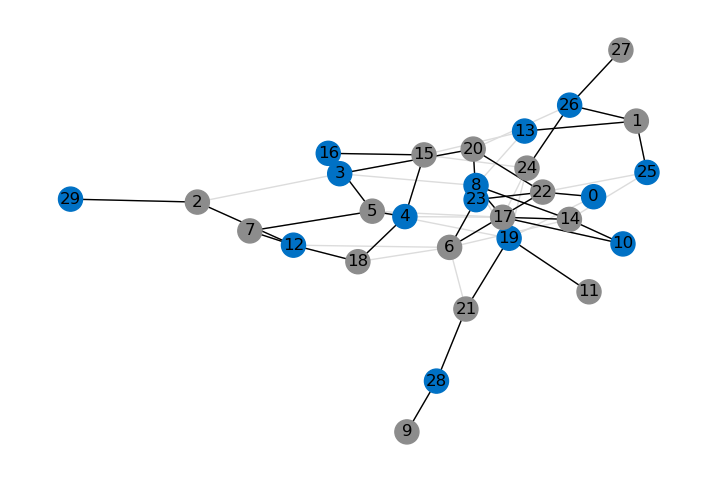

In [12]:
plt.figure(figsize=(9, 6))

nx.draw_networkx_edges(
    G,
    pos=pos,
    edge_color='#dcdcdc',
)

for key in divided:
    subgraph = divided[key]
    colors = [int(i) for i in results[key]]

    subgraph_nodes = list(subgraph.nodes())

    for v in sorted(list(nx.nodes(subgraph))):
        subgraph.nodes[v]['color'] = colors[subgraph_nodes.index(v)]
        G.nodes[v]['color'] = subgraph.nodes[v]['color']

    max_cut_color_map = [
        '#8c8c8c' if subgraph.nodes[u]['color'] == 0
        else '#0071c5' for u in subgraph]

    nx.draw(divided[key], with_labels=True, pos=pos, node_color=max_cut_color_map)

### merge

In [13]:
def vertex_subgraph(divided, u):
    for key in divided:
        if u in divided[key].nodes():
            return key
    return None

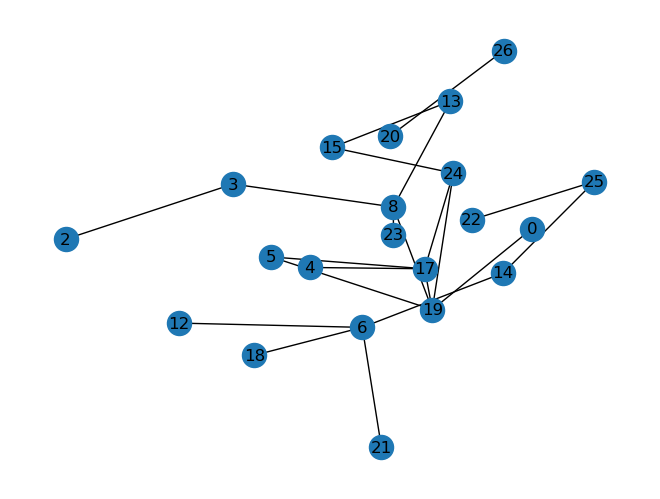

In [14]:
merge_graph = nx.Graph()
internal_edges = list()

for key in divided:
    subgraph = divided[key]
    internal_edges.extend(subgraph.edges())

for u, v in edge_list:
    if (u, v) not in internal_edges and (v, u) not in internal_edges:
        merge_graph.add_edge(u, v)

nx.draw(merge_graph, with_labels=True, pos=pos)

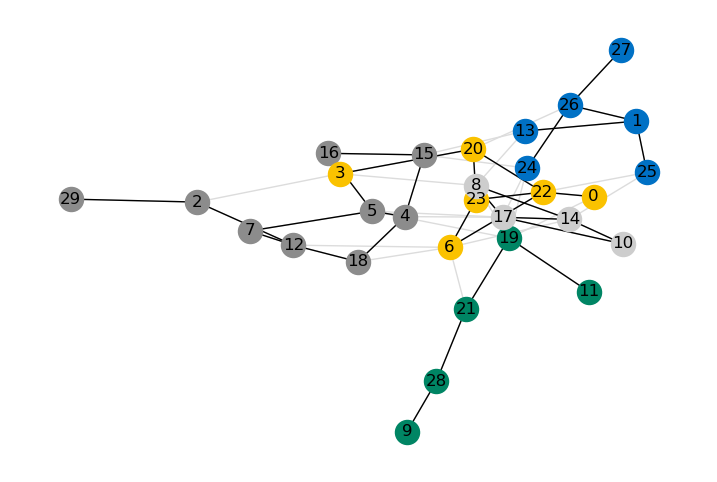

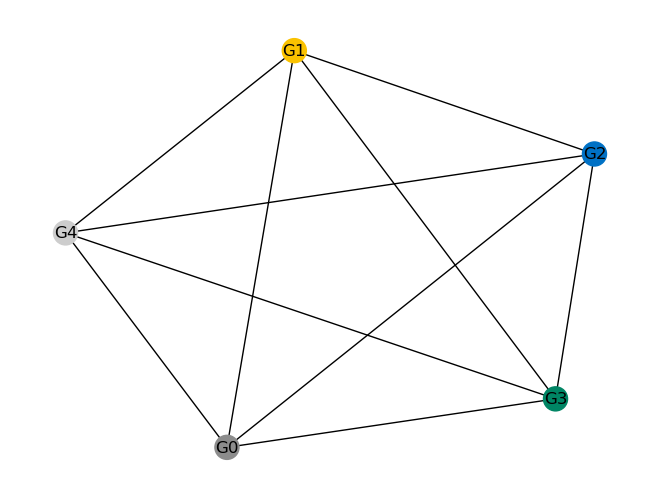

In [15]:
plt.figure(figsize=(9, 6))
nx.draw_networkx_edges(
    G,
    pos=pos,
    edge_color='#dcdcdc',
)

for key in divided:
    nx.draw(divided[key], with_labels=True, pos=pos, node_color=color_dict[key])

plt.show()

H = nx.Graph()
for u, v in merge_graph.edges():
    u_subgraph = vertex_subgraph(divided, u)
    v_subgraph = vertex_subgraph(divided, v)

    if (u_subgraph != v_subgraph):
        H.add_edge(u_subgraph, v_subgraph)

pos_H = nx.spring_layout(H, seed=seed)
color_map_H = [color_dict[u] for u in H.nodes()]

nx.draw(H, with_labels=True, pos=pos_H, node_color=color_map_H)

plt.show()

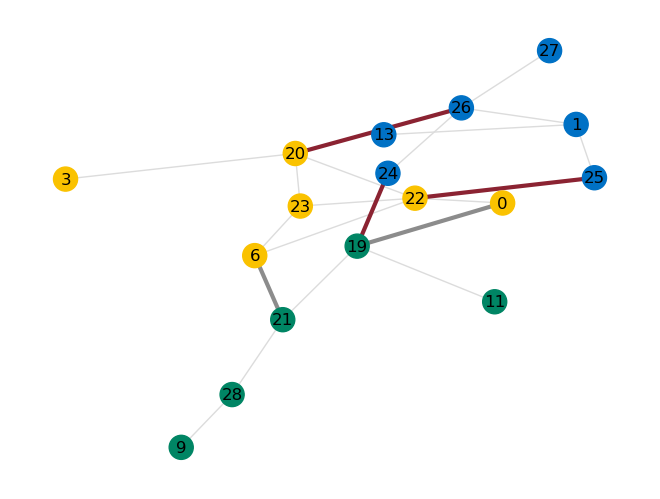

In [16]:
vis_nodes = list()
cut_edges = list()
lef_edges = list()

for key in ['G1', 'G2', 'G3']:
    for u in divided[key]:
        vis_nodes.append(u)

vis_graph = nx.subgraph(G, vis_nodes)
for u, v in vis_graph.edges():
    if vertex_subgraph(divided, u) != vertex_subgraph(divided, v):
        if G.nodes[u]['color'] != G.nodes[v]['color']:
            cut_edges.append((u, v))
        else:
            lef_edges.append((u, v))

nx.draw(
    vis_graph,
    with_labels=True,
    pos=pos,
    node_color=[
        color_dict[vertex_subgraph(divided, u)]
        for u in vis_graph.nodes()],
    edge_color='#dcdcdc'
)
nx.draw_networkx_edges(
    vis_graph,
    pos=pos,
    edgelist=lef_edges,
    edge_color='#8c8c8c',
    width=3
)
nx.draw_networkx_edges(
    vis_graph,
    pos=pos,
    edgelist=cut_edges,
    edge_color='#8b2332',
    width=3
)

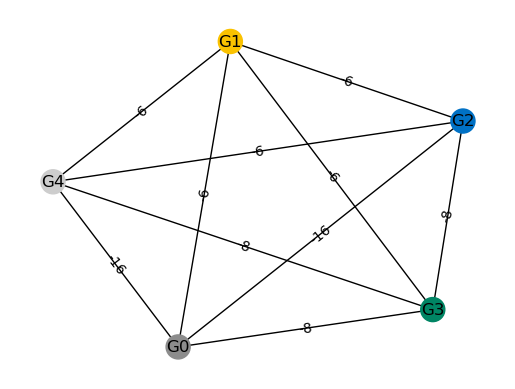

In [17]:
nx.set_edge_attributes(H, 0, 'reward')

for i, j in H.edges():
    reward = 0
    subgraph = divided[i]
    for u in subgraph.nodes():
        for n_u in nx.all_neighbors(G, u):
            if n_u in subgraph:
                if G.nodes[u]['color'] != G.nodes[n_u]['color']:
                    reward -= 1
                else:
                    reward += 1
    
    H[i][j]['reward'] = reward

edge_labels = nx.get_edge_attributes(H, 'reward')
nx.draw_networkx_edge_labels(H, edge_labels=edge_labels, pos=pos_H)
nx.draw(H, node_color=color_map_H, pos=pos_H, with_labels=True)
plt.show()

In [18]:
def merge_hamiltonian(H):
    hamil = 0
    nodes = list(H.nodes())

    for u, v in H.edges():
        qu = nodes.index(u)
        qv = nodes.index(v)
        hamil += H[u][v]['reward'] * spin.z(qu) * spin.z(qv)
    
    return hamil

In [19]:
max_iterations = 250
merge_layer_count = 4
merge_param_count = 2 * merge_layer_count

optimizer = cudaq.optimizers.COBYLA()
optimizer.initial_parameters = np.random.uniform(-np.pi, np.pi, merge_param_count)
optimizer.max_iterations = max_iterations

merge_nodes = list(H.nodes())
qubit_count = len(merge_nodes)

merge_edge_source = list()
merge_edge_target = list()

n_edges = 0
for u, v in H.edges():
    merge_edge_source.append(merge_nodes.index(u))
    merge_edge_target.append(merge_nodes.index(v))
    n_edges += 1

hamil = merge_hamiltonian(H)

In [20]:
optimal_expectation, optimal_parameters = cudaq.vqe(
    kernel=qaoa,
    spin_operator=hamil,
    argument_mapper=lambda parameter_vector: (
        qubit_count,
        merge_layer_count,
        merge_edge_source,
        merge_edge_target,
        n_edges,
        parameter_vector
    ),
    optimizer=optimizer,
    parameter_count=merge_param_count,
    shots=shots
)

print("Optimal Expectation = ", optimal_expectation)

counts = cudaq.sample(
    qaoa,
    qubit_count,
    merge_layer_count,
    merge_edge_source,
    merge_edge_target,
    n_edges,
    optimal_parameters,
    shots_count=shots
)

result = str(counts.most_probable())

Optimal Expectation =  -83.248


In [21]:
result

'11111'